In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import re
from scipy import signal
from pathlib import Path
import logging

In [50]:
logging.basicConfig(
    level=logging.DEBUG,
    format = '%(asctime)s - %(levelname)s - %(message)s',
    handlers = [
        logging.StreamHandler()
    ]
)

In [51]:
logger = logging.getLogger(__name__)

# HDF5
### What is an HDF5 file?
- HDF5 = a container file, not a flat table.

Think of it like:
- A filesystem inside a single file

Just like a disk has folders and files, an HDF5 file has:
- Groups → like folders
- Datasets → like files (arrays, tables, numbers)
- Attributes → metadata (key–value info)

```
myfile.hdf5
│
├── /strain
│    └── strain           ← 1D NumPy-like array (the signal)
│
├── /meta
│    ├── detector         ← "H1" or "L1"
│    ├── sample_rate
│    └── gps_start_time
│
└── /quality
     └── data_flags
```

### Why LIGO uses HDF5
Because LIGO data is:
1. Huge
2. Hierarchical
3. Mixed data types
4. Needs metadata tightly coupled to the signal
5. CSV or Parquet would be a bad fit.

### What’s inside a LIGO HDF5 (practically)

You will almost always find:

1️⃣ Strain (the main thing)

- A 1D array
- Length = sample_rate × duration
- This is what you plot, filter, and model

2️⃣ Metadata

- Sample rate
- GPS time
- Detector name (H1 / L1)
- Units

3️⃣ Quality flags (sometimes)

- Marks bad segments
- Glitches
- Missing data

### One-sentence intuition (lock this in)

**An HDF5 file is a mini data lake: signal + metadata + structure, all in one file.**

In [52]:
DATA_DIR = Path("data/raw")

In [53]:
files = list(DATA_DIR.glob("*.hdf5"))

### LIGO filenames are very informative. Let’s decode them piece by piece.
`
<Observatory>-<Detector>_<Source>_<SampleRate>_<Release>-<GPS_START>-<DURATION>.hdf5
`

| Part         | Meaning                                |
| ------------ | -------------------------------------- |
| `H`          | Hanford observatory                    |
| `H1`         | Hanford detector (interferometer)      |
| `GWOSC`      | Gravitational Wave Open Science Center |
| `4KHZ`       | Sampling rate = **4096 Hz**            |
| `R1`         | Data release version                   |
| `1264316101` | GPS start time (seconds)               |
| `32`         | Duration = **32 seconds**              |
| `.hdf5`      | File format                            |


In [54]:
for file in files:
    logger.info(file)

2026-02-08 17:51:16,576 - INFO - data/raw/H-H1_GWOSC_4KHZ_R1-1264316101-32.hdf5
2026-02-08 17:51:16,588 - INFO - data/raw/L-L1_GWOSC_4KHZ_R1-1264316101-32.hdf5


In [55]:
files[0].name

'H-H1_GWOSC_4KHZ_R1-1264316101-32.hdf5'

In [56]:
type(files)

list

In [57]:
type(DATA_DIR.glob("*.hdf5"))

generator

- files is a list
- But the elements inside the list are NOT strings or numbers
- Each element is a Path object

In [10]:
type(files[0])

pathlib.PosixPath

In [11]:
name = files[0].stem   # filename without .hdf5
parts = name.split("-")

file_start_gps = int(parts[-2])
file_duration  = int(parts[-1])
logger.info(file_start_gps)
logger.info(file_duration)

2026-01-27 19:01:26,025 - INFO - 1264316101
2026-01-27 19:01:26,029 - INFO - 32


In [13]:
with h5py.File(files[0], "r") as f:
    print("Top-level Keys:", list(f.keys()))
    print("\nInside 'Strain':", list(f["strain"].keys()))
    
    dset = f["strain"]["Strain"]
    print("Shape:", dset.shape)
    print("Data Type:", dset.dtype)
    print("First 10 samples:", dset[:10])
    print("DSET Type:", type(dset))
    print(dset[:])

Top-level Keys: ['meta', 'quality', 'strain']

Inside 'Strain': ['GWOSCmeta', 'Strain']
Shape: (131072,)
Data Type: float64
First 10 samples: [7.78093662e-21 1.18189890e-20 1.68268607e-20 1.09831546e-20
 4.77022809e-21 1.61422452e-20 1.93075218e-20 9.89761838e-21
 9.94420316e-21 1.36436917e-20]
DSET Type: <class 'h5py._hl.dataset.Dataset'>
[ 7.78093662e-21  1.18189890e-20  1.68268607e-20 ... -3.39502926e-20
 -2.47413697e-20 -3.03693951e-20]


## Sample Rate
LIGO data is a 1D time-series of strain measurements. A sample is one measurement taken at a specific instant. The sampling rate (e.g., 4096 Hz) means the detector records 4096 samples every second. Time is implicit: sample index × (1 / sampling rate). The duration of a file is total samples ÷ sampling rate (e.g., 131,072 ÷ 4096 = 32 s). Higher sampling rate gives finer time resolution, not longer duration.

### Here’s how size is calculated in that code, step by step, briefly:
1. N = len(strain) → Counts how many samples are in strain.
2. strain.itemsize → Size of one element in bytes (e.g., 8 bytes for a float64).
3. N * strain.itemsize → Total bytes used by all samples.
4. / 1024**2 → Converts bytes to megabytes (MB).

Computers represent data in binary (base-2), so memory sizes are counted in powers of 2, not powers of 10. One byte equals 8 bits. The closest power of 2 to 1000 is 2¹⁰ = 1024, so 1 KB = 1024 bytes. Each larger unit adds another factor of 1024: 1 MB = 2²⁰ bytes, 1 GB = 2³⁰ bytes. This convention aligns memory measurement with how computers actually store and address data.

In [14]:
with h5py.File(files[0], "r") as f:
    strain = f["strain"]["Strain"][:]

In [15]:
strain

array([ 7.78093662e-21,  1.18189890e-20,  1.68268607e-20, ...,
       -3.39502926e-20, -2.47413697e-20, -3.03693951e-20])

In [16]:
len(strain)

131072

In [17]:
strain.itemsize

8

In [18]:
N = len(strain)
each_strain_size = strain.itemsize
logger.info(f"Approx Total Strain/memory Size: {(N * each_strain_size)/1024 ** 2} MB")

2026-01-27 19:02:51,631 - INFO - Approx Total Strain/memory Size: 1.0 MB


In [21]:
strain[:5]

array([7.78093662e-21, 1.18189890e-20, 1.68268607e-20, 1.09831546e-20,
       4.77022809e-21])

`total_time = total_samples ÷ samples_per_second`

`131072 ÷ 4096 = 32 seconds`

In [22]:
fs = 4096

# Return evenly spaced values within a given interval.
t = np.arange(len(strain)) / fs
t

array([0.00000000e+00, 2.44140625e-04, 4.88281250e-04, ...,
       3.19992676e+01, 3.19995117e+01, 3.19997559e+01])

In [23]:
131072/4096

32.0

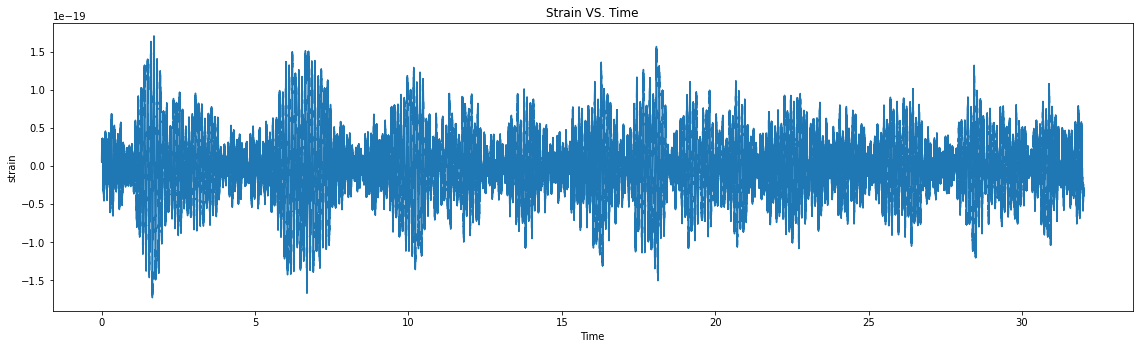

In [24]:
fig = plt.figure(figsize=(15, 4))
axes = fig.add_axes([0, 0, 1, 1])
axes.set_xlabel("Time")
axes.set_ylabel("strain")
axes.set_title("Strain VS. Time")
axes.plot(t, strain)

#### The real difference np.linspace and np.arange:

**np.linspace(start, stop, N):**
→ exactly N evenly spaced points (step is computed)
`np.linspace(0, 1, 4)`
`[0.00, 0.33, 0.67, 1.00]  ← evenly spaced, not random`


**np.arange(start, stop, step):**
→ exact step size, number of points depends on it
`np.arange(0, 1, 0.25)`
`[0.00, 0.25, 0.50, 0.75]`

# Time ↔ Sample Index Conversion (Clean Intuition)

## Core idea
LIGO data is stored as **samples**, not time.  
The **sampling rate (`fs`)** tells us how many samples are taken per second.

---

## What is sampling rate?
- `fs = 4096 Hz`  
- Meaning: **4096 samples every 1 second**

---

## Two conversion rules (memorize these)

### 1️⃣ Time → Sample index (MULTIPLY)
Use this when you want to know **which sample corresponds to a time**.

**Formula:**
sample_index = time_in_seconds × fs


**Example:**
- 1 second → `1 × 4096 = 4096`
- 10 seconds → `10 × 4096 = 40960`

Interpretation:  
> How many samples have occurred by this time?

---

### 2️⃣ Sample index → Time (DIVIDE)
Use this when you want to know **what time a sample represents**.

**Formula:**
time_in_seconds = sample_index ÷ fs


**Example:**
- sample 4096 → `4096 ÷ 4096 = 1 second`
- sample 2048 → `2048 ÷ 4096 = 0.5 seconds`

Interpretation:  
> How many seconds does this many samples represent?

---

## Why both are needed
- **Multiply** → choose where to zoom or slice
- **Divide** → label the x-axis in plots

---

## Analogy (video frames)
- Frames per second (FPS) ≈ samples per second (fs)
- Time → frame number → multiply
- Frame number → time → divide

---

## One-line takeaway
**Multiply to go from time to samples.  
Divide to go from samples to time.**


In [25]:
start_sec = 0
duration = 2

start_idx = int(start_sec * fs)
end_idx = int(((start_sec + duration) * fs ))

print("Start Index:", start_idx, "END Index:", end_idx, "Number of Samples:", end_idx - start_idx)

Start Index: 0 END Index: 8192 Number of Samples: 8192


In [28]:
noise = strain[start_idx:end_idx]

In [29]:
noise

array([7.78093662e-21, 1.18189890e-20, 1.68268607e-20, ...,
       4.08194840e-20, 4.61687241e-20, 5.11603667e-20])

In [35]:
start_signal_sec = 16
signal_duration = 0.5

start_signal_idx = int(start_signal_sec * fs)
end_signal_idx = int(((start_signal_sec + signal_duration) * fs ))

print("Start Index:", start_signal_idx, "END Index:", end_signal_idx, "Number of Samples:", end_signal_idx - start_signal_idx)

Start Index: 65536 END Index: 67584 Number of Samples: 2048


In [36]:
signal = strain[start_signal_idx:end_signal_idx]

In [37]:
signal

array([1.94824281e-20, 1.37637239e-20, 3.29507773e-20, ...,
       6.80869188e-20, 5.61540522e-20, 5.13746985e-20])

In [39]:
len(signal)

2048

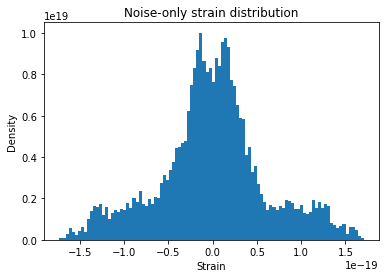

In [40]:
plt.figure(figsize=(6,4))
plt.hist(noise, bins=100, density=True, )
plt.xlabel("Strain")
plt.ylabel("Density")
plt.title("Noise-only strain distribution")
plt.show()

2026-01-27 19:18:34,849 - INFO - NumExpr defaulting to 8 threads.


<AxesSubplot:ylabel='Count'>

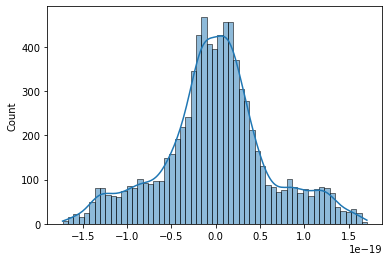

In [41]:
sns.histplot(noise, kde=True)

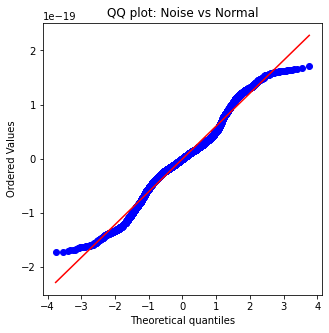

In [42]:
import scipy.stats as stats

plt.figure(figsize=(5,5))
stats.probplot(noise, dist="norm", plot=plt)
plt.title("QQ plot: Noise vs Normal")
plt.show()

In [43]:
noise.mean()

-2.908527053138233e-22

In [44]:
noise.std(ddof=1)

6.117853193111119e-20

In [79]:
zoom = strain[start_idx:end_idx]

In [80]:
t_zoom = np.arange(len(zoom))/fs + start_sec

array([7.78093662e-21, 1.18189890e-20, 1.68268607e-20, ...,
       1.51702897e-20, 1.28219553e-20, 1.42203726e-20])

array([7.78093662e-21, 1.18189890e-20, 1.68268607e-20, ...,
       4.08194840e-20, 4.61687241e-20, 5.11603667e-20])

In [45]:
strain

array([ 7.78093662e-21,  1.18189890e-20,  1.68268607e-20, ...,
       -3.39502926e-20, -2.47413697e-20, -3.03693951e-20])

In [46]:
len(strain)

131072

<AxesSubplot:ylabel='Count'>

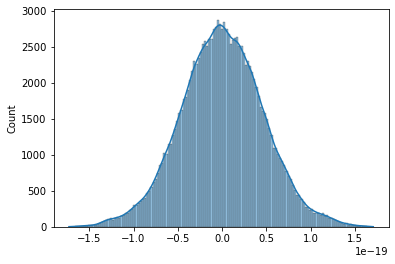

In [48]:
sns.histplot(strain, kde = True)